# Silver Layer: QC and Normalization

This notebook transforms bronze layer data into silver layer:
- Apply condition-aware QC filtering
- Normalize counts (standard + SCTransform)
- Select highly variable genes (HVGs)
- Diagnose batch effects
- Save versioned `.h5ad` file

**Input:** `data/bronze/osd352_brain/ingest_date=2026-03-12/`

**Output:** `data/silver/osd352_brain_v1_qc.h5ad`

## Step 1: Load Bronze Layer Data

Load the bronze layer files (obs.parquet, var.parquet, X.h5) and reconstruct AnnData object.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import h5py
import scanpy as sc
import scipy.sparse as sp


In [2]:
# Load bronze layer files
bronze_dir = Path('../data/bronze/osd352_brain/ingest_date=2026-03-12')

# Load metadata
obs = pd.read_parquet(bronze_dir / 'obs.parquet')
var = pd.read_parquet(bronze_dir / 'var.parquet')

# Load sparse count matrix
with h5py.File(bronze_dir / 'X.h5', 'r') as f:
    data = f['data'][:]
    indices = f['indices'][:]
    indptr = f['indptr'][:]
    shape = f['shape'][:]

# Reconstruct sparse CSR matrix
X = sp.csr_matrix(
    (data, indices, indptr), 
    shape=shape
)

# Create AnnData object
adata = sc.AnnData(
    X=X, 
    obs=obs, 
    var=var
)

print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Columns: {adata.obs.columns.tolist()}")


Loaded: 32243 cells × 32285 genes
Columns: ['ingest_date', 'source_file', 'dataset_id', 'organism', 'tissue', 'technology', 'genome_build', 'processing_pipeline']


In [3]:
# Extract sample ID from barcode suffix (e.g., "ACGT-1" → "1")
adata.obs['sample_id'] = adata.obs.index.str.split('-').str[-1]

# Verified mapping from notebook 01 (matched by cell counts)
sample_map = {
    '1': 'RR3_BRN_FLT_F2',
    '2': 'RR3_BRN_FLT_F7',
    '3': 'RR3_BRN_GC_G8',
    '4': 'RR3_BRN_GC_G9',
    '5': 'RR3_BRN_FLT_F1'
}

condition_map = {
    '1': 'Space Flight',
    '2': 'Space Flight',
    '3': 'Ground Control',
    '4': 'Ground Control',
    '5': 'Space Flight'
}

adata.obs['sample_name'] = adata.obs['sample_id'].map(sample_map)
adata.obs['condition'] = adata.obs['sample_id'].map(condition_map)

# Verify
print(adata.obs[['sample_id', 'sample_name', 'condition']].drop_duplicates())
print(f"\nCells per condition: {adata.obs['condition'].value_counts().to_dict()}")


                   sample_id     sample_name       condition
AAACAGCCAACAACAA-5         5  RR3_BRN_FLT_F1    Space Flight
AAACAGCCAATAATCC-4         4   RR3_BRN_GC_G9  Ground Control
AAACAGCCAATCGCAC-3         3   RR3_BRN_GC_G8  Ground Control
AAACAGCCACTAAGTT-1         1  RR3_BRN_FLT_F2    Space Flight
AAACATGCAAAGCTAA-2         2  RR3_BRN_FLT_F7    Space Flight

Cells per condition: {'Space Flight': 21661, 'Ground Control': 10582}


In [4]:
# Flag mitochondrial genes (mouse genome uses "mt-" prefix)
adata.var['mt'] = adata.var_names.str.startswith('mt-')

mt_count = adata.var['mt'].sum()
print(f"Mitochondrial genes found: {mt_count}")

# Calculate QC metrics (adds n_genes_by_counts, total_counts, pct_counts_mt to obs)
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Quick summary
print(f"\nGenes per cell:  min={adata.obs['n_genes_by_counts'].min()}, "
      f"median={adata.obs['n_genes_by_counts'].median():.0f}, "
      f"max={adata.obs['n_genes_by_counts'].max()}")

print(f"UMI per cell:    min={adata.obs['total_counts'].min():.0f}, "
      f"median={adata.obs['total_counts'].median():.0f}, "
      f"max={adata.obs['total_counts'].max():.0f}")

print(f"Mt %:            mean={adata.obs['pct_counts_mt'].mean():.2f}%, "
      f"max={adata.obs['pct_counts_mt'].max():.2f}%")


Mitochondrial genes found: 13

Genes per cell:  min=31, median=928, max=9553
UMI per cell:    min=33, median=1550, max=74170
Mt %:            mean=0.14%, max=31.13%


## Step 4: Condition-Aware QC Filtering

We use different mitochondrial thresholds per condition to preserve biologically 
relevant stressed cells in Space Flight samples:

**Thresholds:**
- Min genes per cell: 200 (filters empty/low-quality droplets)
- Min UMI counts: 500 (removes debris, standard for snRNA-seq)
- Max UMI counts: 50,000 (removes likely doublets — our max is ~74k)
- Mt % (Ground Control): <5% (standard threshold)
- Mt % (Space Flight): <10% (lenient — elevated mt% is real spaceflight biology)

**Why condition-aware?**
Space Flight samples show elevated mitochondrial content (up to ~31%) due to cellular stress.
A uniform 5% cutoff would remove stressed-but-real cells from Flight samples, losing 
biological signal. Ground Control cells above 5% are more likely technical artifacts.


In [5]:
cells_before = adata.n_obs

# Universal thresholds
min_genes = 200
min_counts = 500
max_counts = 50000

# Condition-aware mt% thresholds
mt_threshold_gc = 5.0
mt_threshold_flight = 10.0

# Build mt mask per condition
is_gc = adata.obs['condition'] == 'Ground Control'
is_flight = adata.obs['condition'] == 'Space Flight'

mt_pass_gc = adata.obs.loc[is_gc, 'pct_counts_mt'] < mt_threshold_gc
mt_pass_flight = adata.obs.loc[is_flight, 'pct_counts_mt'] < mt_threshold_flight

# Combine: True if cell passes its condition-specific mt threshold
mt_pass = pd.Series(False, index=adata.obs.index)
mt_pass[mt_pass_gc.index] = mt_pass_gc
mt_pass[mt_pass_flight.index] = mt_pass_flight

# Apply all filters
keep = (
    (adata.obs['n_genes_by_counts'] >= min_genes)
    & (adata.obs['total_counts'] >= min_counts)
    & (adata.obs['total_counts'] <= max_counts)
    & mt_pass
)

adata = adata[keep].copy()

cells_after = adata.n_obs
cells_removed = cells_before - cells_after

print(f"Cells before QC: {cells_before:,}")
print(f"Cells after QC:  {cells_after:,}")
print(f"Cells removed:   {cells_removed:,} ({cells_removed/cells_before*100:.1f}%)")
print(f"\nPer condition:")
print(adata.obs['condition'].value_counts().to_dict())


Cells before QC: 32,243
Cells after QC:  27,968
Cells removed:   4,275 (13.3%)

Per condition:
{'Space Flight': 17972, 'Ground Control': 9996}


## Step 5: Normalization

Two-step standard normalization:
1. **Total count normalization** — scale each cell to 10,000 total counts. This removes 
   library size differences (some cells are sequenced deeper than others).
2. **Log1p transform** — log(x + 1). Compresses the dynamic range so highly expressed 
   genes don't dominate downstream analysis (PCA, clustering).

We also store the raw counts in `adata.raw` before normalizing — useful for 
differential expression later (some DE methods need raw counts).


In [6]:
# Save raw counts before normalization (needed for DE analysis later)
adata.raw = adata

# Step 1: Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Step 2: Log transform
sc.pp.log1p(adata)

print(f"Normalization complete: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Raw counts preserved in adata.raw: {adata.raw.n_obs} × {adata.raw.n_vars}")


Normalization complete: 27968 cells × 32285 genes
Raw counts preserved in adata.raw: 27968 × 32285


## Step 6: Highly Variable Gene (HVG) Selection

Select the top 2,000 most variable genes across cells. These genes carry the 
biological signal — they differ between cell types and conditions. The remaining 
~30k genes are mostly housekeeping or low-expression noise.

We use Scanpy's `flavor='seurat_v3'` method which works well with count data 
and is the current standard in the field.


In [7]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor='seurat_v3'
)

hvg_count = adata.var['highly_variable'].sum()
print(f"Highly variable genes selected: {hvg_count}")
print(f"Total genes retained in adata.var: {adata.n_vars}")
print(f"\nNote: All genes still in adata, HVGs flagged in adata.var['highly_variable']")
print(f"Downstream steps (PCA, clustering) will use HVGs only")


/var/folders/yx/0p787bk16dn_6tly0kvlgy740000gn/T/ipykernel_80718/1331169460.py:1: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(


Highly variable genes selected: 2000
Total genes retained in adata.var: 32285

Note: All genes still in adata, HVGs flagged in adata.var['highly_variable']
Downstream steps (PCA, clustering) will use HVGs only


## Step 7: Batch Effect Diagnostic

Run PCA and UMAP on HVGs, then visualize by sample_id vs condition.

**What to look for:**
- If cells cluster by `condition` → biological signal, no batch correction needed
- If cells cluster by `sample_id` → batch effect, need Combat or Harmony
- Mixed/overlapping → good, means samples are comparable


In [8]:
# Scale gene expression (zero mean, unit variance) — required before PCA
sc.pp.scale(adata, max_value=10)

# PCA on HVGs only
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

# Compute neighborhood graph (needed for UMAP)
sc.pp.neighbors(adata, n_pcs=30)

# UMAP embedding
sc.tl.umap(adata)

print("PCA + UMAP complete")


/Users/harry/miniforge3/envs/spaceGen/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/yx/0p787bk16dn_6tly0kvlgy740000gn/T/ipykernel_80718/3821067229.py:5: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(adata, n_comps=50, use_highly_variable=True)


PCA + UMAP complete


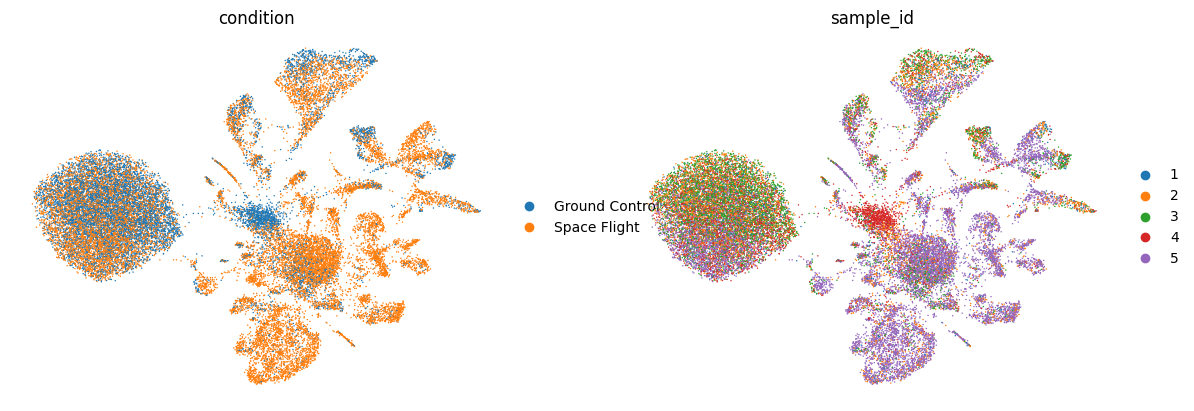

In [9]:
# Side-by-side UMAP: condition vs sample_id
sc.pl.umap(adata, color=['condition', 'sample_id'], ncols=2, frameon=False)


In [10]:
# Check sample 4 QC metrics vs others
print(adata.obs.groupby('sample_name')[
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
].median().round(2))


                n_genes_by_counts  total_counts  pct_counts_mt
sample_name                                                   
RR3_BRN_FLT_F1             1286.0        2269.0           0.06
RR3_BRN_FLT_F2             1115.0        2111.0           0.04
RR3_BRN_FLT_F7             1028.5        1806.5           0.04
RR3_BRN_GC_G8              1010.0        1758.0           0.05
RR3_BRN_GC_G9               909.5        1454.5           0.08


/var/folders/yx/0p787bk16dn_6tly0kvlgy740000gn/T/ipykernel_80718/3020811304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby('sample_name')[


## Step 8: Save Silver Layer

Save the QC-filtered, normalized AnnData as versioned `.h5ad` file.
This contains:
- 27,968 QC-passed cells (from 32,243 original)
- Normalized + log-transformed expression
- 2,000 HVGs flagged
- PCA, UMAP embeddings
- Raw counts preserved in `adata.raw`


In [11]:
# Create silver output directory
silver_dir = Path('../data/silver')
silver_dir.mkdir(parents=True, exist_ok=True)

# Save as versioned h5ad
output_path = silver_dir / 'osd352_brain_v1_qc.h5ad'
adata.write(output_path)

# Verify
file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"Saved: {output_path}")
print(f"Size: {file_size_mb:.1f} MB")
print(f"Shape: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Raw counts preserved: {adata.raw is not None}")


Saved: ../data/silver/osd352_brain_v1_qc.h5ad
Size: 7236.5 MB
Shape: 27968 cells × 32285 genes
Raw counts preserved: True


## Summary

**Silver layer complete for OSD-352 brain tissue (v1)**

| Metric | Value |
|--------|-------|
| Cells before QC | 32,243 |
| Cells after QC | 27,968 (13.3% removed) |
| Space Flight cells | 17,972 |
| Ground Control cells | 9,996 |
| Genes | 32,285 (2,000 HVGs) |
| Normalization | Total count (10k) + log1p |
| QC approach | Condition-aware mt% thresholds |
| Batch effects | None detected (UMAP shows good mixing) |
| Output | `data/silver/osd352_brain_v1_qc.h5ad` |

**Key decisions:**
- Condition-aware QC: GC <5% mt, Flight <10% mt (preserves stressed cells)
- No batch correction needed (samples mix well in UMAP)
- Sample G9 clusters separately but QC metrics are normal — biological, not technical
- Spaceflight-enriched clusters visible in UMAP — investigate in gold layer


## Step 9: Fix File Size

`sc.pp.scale()` converted the sparse matrix to dense (~7 GB). The scaled data
is no longer needed — PCA and UMAP embeddings are already stored in `adata.obsm`.
Drop the scaled layer, rebuild X from raw counts (re-normalize), and re-save.

In [12]:
# Drop the scaled layer — PCA/UMAP are already computed and stored
if 'scaled' in adata.layers:
    del adata.layers['scaled']

# Rebuild X from raw counts: re-normalize to get sparse log-normalized matrix
adata.X = adata.raw.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Verify X is sparse again
print(f"X type: {type(adata.X)}")
print(f"Layers: {list(adata.layers.keys())}")

# Re-save
output_path = Path('../data/silver/osd352_brain_v1_qc.h5ad')
adata.write(output_path)

file_size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"New size: {file_size_mb:.1f} MB")


X type: <class 'scipy.sparse._csr.csr_matrix'>
Layers: []
New size: 654.0 MB
